In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)
n = 50
real_1d = np.cumsum(np.random.randn(n))  # Trayectoria real (posición)

# Observaciones con ruido
noise = np.random.normal(0, 2, size=n)  # Ruido de medición
observed_1d = real_1d + noise           # Señal medida ruidosa

In [3]:
# Inicialización
x_hat = 0           # Estimación inicial
P = 1               # Incertidumbre inicial
Q = 0.001           # Varianza del proceso (ruido interno)
R = 4               # Varianza de medición (ruido externo)
estimate_1d = []    # Lista para guardar las estimaciones

for z in observed_1d:
    # Predicción
    x_hat_prior = x_hat
    P_prior = P + Q

    # Actualización
    K = P_prior / (P_prior + R)
    x_hat = x_hat_prior + K * (z - x_hat_prior)
    P = (1 - K) * P_prior

    estimate_1d.append(x_hat)

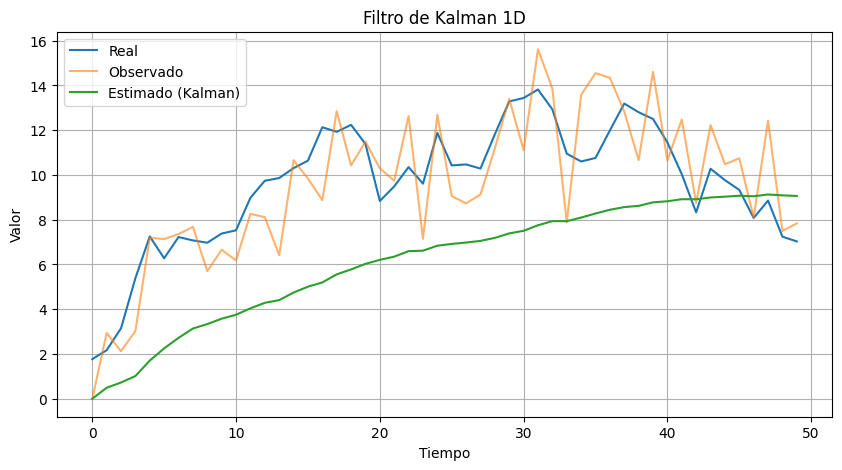

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(real_1d, label='Real')
plt.plot(observed_1d, label='Observado', alpha=0.6)
plt.plot(estimate_1d, label='Estimado (Kalman)')
plt.legend()
plt.title('Filtro de Kalman 1D')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()